# Image-Style Biaxial Fault Friction Benchmark (Paper-Faithful NCP)

This notebook tests friction on a **closed, prestressed inclined fault** under an image-style loading path that is much closer to the geomechanics sketch than the older top-shortening sliding-block benchmark.

The key choices here are deliberate:

- **Paper-faithful Macklin NCP friction**: `friction_law="compliance"`, `inactive_handling="hard_zero"`
- **Roller-style supports** on the left and bottom boundaries
- **Ramped biaxial compression** on the right and top boundaries
- **No artificial shear prestress patch by default**: `background_ratio = 0`, `patch_ratio = 0`

So this notebook is a cleaner friction test: the fault starts closed under normal prestress, then we perturb it with a gradual far-field compression ramp instead of trying to slam the interface shut in one step.

Note: this is still a **kinematic proxy** of the sketch because the current FE helper path prescribes displacement rates on the loaded faces rather than true Neumann tractions. That is enough to test whether the frictional NCP path behaves sensibly under a prestressed biaxial compression scenario.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "examples").exists():
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from examples.biaxial_fault_friction_ncp_helpers import (
    build_biaxial_fault_ncp_context,
    normalized_fault_from_image,
    run_biaxial_fault_ncp_history,
    summarize_history,
)

np.set_printoptions(precision=4, suppress=True)
plt.rcParams["figure.figsize"] = (10, 4)


In [2]:
geom = normalized_fault_from_image()

BASE_CONFIG = {
    "xmin": geom["xmin"],
    "xmax": geom["xmax"],
    "ymin": geom["ymin"],
    "ymax": geom["ymax"],
    "fault_x0": geom["fault_x0"],
    "fault_y0": geom["fault_y0"],
    "fault_theta": geom["fault_theta"],
    "fault_length": geom["fault_length"],
    "n_elem": 12,
    "element_type": "tri",
    "normal_prestress": 6.6,
    "background_ratio": 0.0,
    "patch_ratio": 0.0,
    "patch_half_width": 0.08,
    "right_v1_rate": -0.005,
    "top_v2_rate": -0.0025,
    "normal_r": 0.5,
    "friction_r": 0.5,
    "gap_tol": 1.0e-12,
    "ncp_type": "fischer_burmeister",
}

RUN_CONFIG = {
    "t_end_hours": 2.5e-3,
    "n_steps": 200,
    "adaptive": True,
    "time_method": "backward_euler",
}

CASE_MUS = [0.0, 0.6]

config_summary = pd.DataFrame(
    {
        "value": [
            BASE_CONFIG["n_elem"],
            f"({geom['fault_x1']:.3f}, {geom['fault_y1']:.3f}) -> ({geom['fault_x2']:.3f}, {geom['fault_y2']:.3f})",
            np.degrees(BASE_CONFIG["fault_theta"]),
            BASE_CONFIG["normal_prestress"],
            BASE_CONFIG["background_ratio"],
            BASE_CONFIG["patch_ratio"],
            BASE_CONFIG["right_v1_rate"],
            BASE_CONFIG["top_v2_rate"],
            RUN_CONFIG["t_end_hours"],
            CASE_MUS,
        ]
    },
    index=[
        "mesh resolution",
        "fault segment",
        "fault angle [deg]",
        "normal prestress",
        "background shear ratio",
        "patch shear ratio",
        "right compression rate",
        "top compression rate",
        "final time [hr]",
        "mu cases",
    ],
)
display(config_summary)


,value
mesh resolution,12
fault segment,"(0.200, 0.205) -> (0.800, 0.805)"
fault angle [deg],45.0
normal prestress,6.6
background shear ratio,0.0
patch shear ratio,0.0
right compression rate,-0.005
top compression rate,-0.0025
final time [hr],0.0025
mu cases,"[0.0, 0.6]"


In [3]:
contexts = {}
histories = {}
rows = []

for mu in CASE_MUS:
    cfg = dict(BASE_CONFIG)
    cfg["mu_friction"] = float(mu)
    ctx = build_biaxial_fault_ncp_context(**cfg)
    hist = run_biaxial_fault_ncp_history(
        ctx=ctx,
        label=f"mu={mu:.2f}",
        **RUN_CONFIG,
    )
    summary = summarize_history(ctx, hist)
    summary["mu_case"] = float(mu)
    contexts[mu] = ctx
    histories[mu] = hist
    rows.append(summary)

summary_df = pd.DataFrame(rows)[[
    "mu_case",
    "success",
    "reached_final_time",
    "accepted_steps",
    "failed_steps",
    "max_penetration",
    "max_abs_slip",
    "max_abs_pn_total",
    "max_abs_pt_total",
    "max_coulomb_ratio",
    "max_coulomb_excess",
    "max_step_solver_error",
    "max_step_residual_inf",
]]
display(summary_df)


,mu_case,success,reached_final_time,accepted_steps,failed_steps,max_penetration,max_abs_slip,max_abs_pn_total,max_abs_pt_total,max_coulomb_ratio,max_coulomb_excess,max_step_solver_error,max_step_residual_inf
0,0.0,True,True,23,0,0.021988,0.00517,6.660507,0.000000,0.000000,0.0,0.000034,0.000052
1,0.6,True,True,23,0,0.007900,0.00105,6.651234,0.009336,0.002339,0.0,0.000494,0.000035


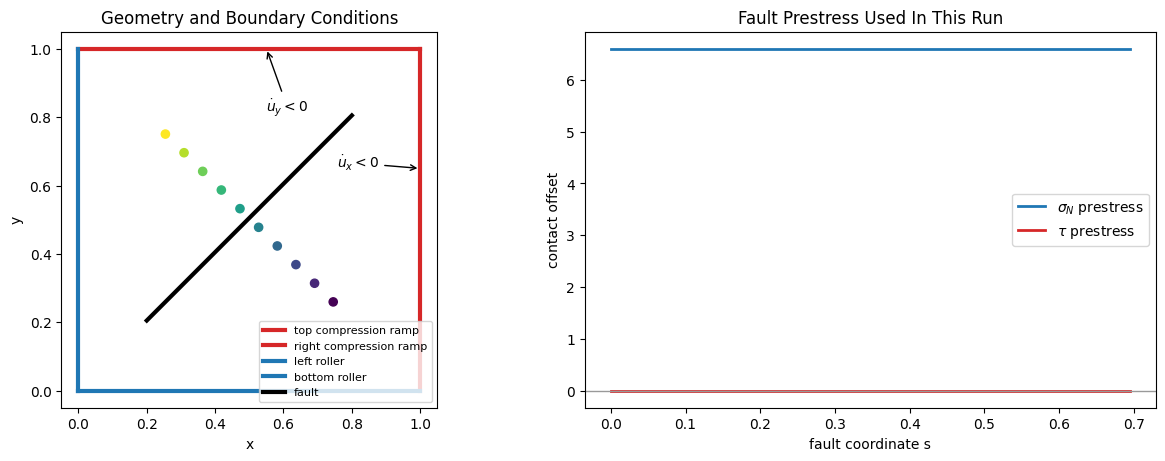

In [4]:
ctx_ref = contexts[CASE_MUS[-1]]
g = ctx_ref["geometry"]
fault_x0 = g["fault_x0"]
fault_y0 = g["fault_y0"]
fault_theta = g["fault_theta"]
fault_length = g["fault_length"]
dx = 0.5 * fault_length * np.cos(fault_theta)
dy = 0.5 * fault_length * np.sin(fault_theta)
x1, x2 = fault_x0 - dx, fault_x0 + dx
y1, y2 = fault_y0 - dy, fault_y0 + dy

contact_coords = np.asarray(ctx_ref["contact_plot"]["contact_coords"], dtype=float)
perm = ctx_ref["contact_plot"]["contact_perm"]
contact_s = ctx_ref["contact_plot"]["contact_s"][perm]
tau_background = ctx_ref["prestress_background"]["tau_profile"][perm]
normal_line = np.full_like(contact_s, ctx_ref["prestress_target"]["normal_prestress"], dtype=float)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)

ax = axes[0]
ax.plot([g["xmin"], g["xmax"]], [g["ymax"], g["ymax"]], color="tab:red", linewidth=3, label="top compression ramp")
ax.plot([g["xmax"], g["xmax"]], [g["ymin"], g["ymax"]], color="tab:red", linewidth=3, label="right compression ramp")
ax.plot([g["xmin"], g["xmin"]], [g["ymin"], g["ymax"]], color="tab:blue", linewidth=3, label="left roller")
ax.plot([g["xmin"], g["xmax"]], [g["ymin"], g["ymin"]], color="tab:blue", linewidth=3, label="bottom roller")
ax.plot([x1, x2], [y1, y2], color="black", linewidth=3, label="fault")
ax.scatter(contact_coords[:, 0], contact_coords[:, 1], c=np.arange(len(contact_coords)), cmap="viridis", s=35, zorder=3)
ax.annotate(r"$\dot u_x<0$", xy=(g["xmax"], 0.65), xytext=(g["xmax"] - 0.12, 0.65), arrowprops={"arrowstyle": "->"}, ha="right")
ax.annotate(r"$\dot u_y<0$", xy=(0.55, g["ymax"]), xytext=(0.55, g["ymax"] - 0.14), arrowprops={"arrowstyle": "->"}, va="top")
ax.set_aspect("equal")
ax.set_title("Geometry and Boundary Conditions")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend(loc="lower right", fontsize=8)

ax = axes[1]
ax.plot(contact_s, normal_line, color="tab:blue", linewidth=2, label=r"$\sigma_N$ prestress")
ax.plot(contact_s, tau_background, color="tab:red", linewidth=2, label=r"$\tau$ prestress")
ax.axhline(0.0, color="0.6", linewidth=1)
ax.set_title("Fault Prestress Used In This Run")
ax.set_xlabel("fault coordinate s")
ax.set_ylabel("contact offset")
ax.legend()

plt.show()


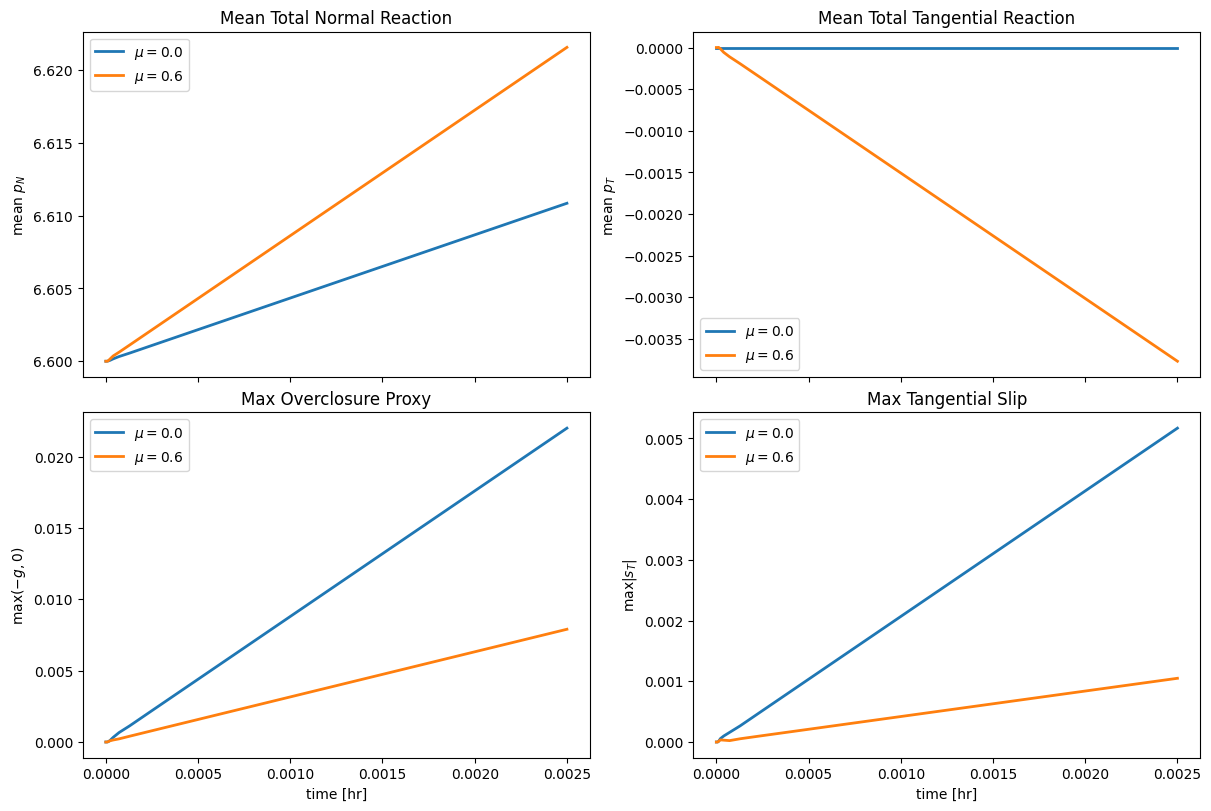

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True, sharex=True)

for mu in CASE_MUS:
    hist = histories[mu]
    t = hist["times_hours"]
    mean_pn = hist["pn_total_history"].mean(axis=1)
    mean_pt = hist["pt_total_history"].mean(axis=1)
    max_overclosure = np.maximum(-hist["gap_history"], 0.0).max(axis=1)
    max_slip = np.abs(hist["slip_history"]).max(axis=1)
    axes[0, 0].plot(t, mean_pn, linewidth=2, label=fr"$\mu={mu}$")
    axes[0, 1].plot(t, mean_pt, linewidth=2, label=fr"$\mu={mu}$")
    axes[1, 0].plot(t, max_overclosure, linewidth=2, label=fr"$\mu={mu}$")
    axes[1, 1].plot(t, max_slip, linewidth=2, label=fr"$\mu={mu}$")

axes[0, 0].set_title("Mean Total Normal Reaction")
axes[0, 0].set_ylabel("mean $p_N$")
axes[0, 0].legend()

axes[0, 1].set_title("Mean Total Tangential Reaction")
axes[0, 1].set_ylabel("mean $p_T$")
axes[0, 1].legend()

axes[1, 0].set_title("Max Overclosure Proxy")
axes[1, 0].set_ylabel(r"$\max(-g, 0)$")
axes[1, 0].set_xlabel("time [hr]")
axes[1, 0].legend()

axes[1, 1].set_title("Max Tangential Slip")
axes[1, 1].set_ylabel(r"$\max |s_T|$")
axes[1, 1].set_xlabel("time [hr]")
axes[1, 1].legend()

plt.show()


## Notes

- This notebook is intentionally the **compression-stage** benchmark only. It does not add an injection/source perturbation yet.
- The default case keeps the fault closed with **normal prestress only** and lets the ramped biaxial compression generate the additional frictional response.
- If you want to push the friction solver harder, the first knobs to turn are `right_v1_rate`, `top_v2_rate`, `t_end_hours`, and `n_elem`.
- If you want to introduce a nucleation patch later, increase `background_ratio` and/or `patch_ratio` from zero. Keeping them at zero is useful here because it isolates the friction response to the biaxial loading path.